Importaciones y configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import yaml

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from src.extract.extract_eam import extraer_eam
from src.extract.extract_excel import extraer_anexo

with open(BASE_DIR / "config" / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

fuentes = config["sources"]
columnas_eam = config["constant"]["columnas_eam"]
grupos_agro = config["constant"]["grupos_agro"]

Extraer y unir las dos EAM

In [2]:
eam_2024 = extraer_eam(BASE_DIR / fuentes["eam_2024"]["path"], "stata", columnas_eam)
eam_2021 = extraer_eam(BASE_DIR / fuentes["eam_2021"]["path"], "csv", columnas_eam)

eam = pd.concat([eam_2021, eam_2024], ignore_index=True)
eam.info()

Empezando a extraer EAM desde c:\Users\Usuario\Documents\Gestion de Almacenamiento de Datos\proyecto_etl_agroindustria\data\bronze\eam\EAM_ANONIMIZADA_2024.dta...
EAM extraída: 6583 filas y 10 columnas
Empezando a extraer EAM desde c:\Users\Usuario\Documents\Gestion de Almacenamiento de Datos\proyecto_etl_agroindustria\data\bronze\eam\EAM_ANONIMIZADA_2021.csv...
EAM extraída: 7138 filas y 10 columnas
<class 'pandas.DataFrame'>
RangeIndex: 13721 entries, 0 to 13720
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nordemp   13721 non-null  float64
 1   nordest   13721 non-null  float64
 2   dpto      13721 non-null  float64
 3   ciiu4     13721 non-null  float64
 4   periodo   13721 non-null  float64
 5   PRODBR2   13721 non-null  float64
 6   INVEBRTA  13721 non-null  float64
 7   PERSOCU   13721 non-null  float64
 8   VALAGRI   13721 non-null  float64
 9   VALORVEN  13721 non-null  float64
dtypes: float64(10)
memory usa

Calidad del Dato

In [3]:
print("Nulos por columna:")
print(eam.isna().sum())

print("\nDuplicados establecimiento-año:", eam.duplicated(subset=["nordest", "periodo"]).sum())

eam[["PERSOCU", "VALAGRI", "VALORVEN"]].describe().round(0)

Nulos por columna:
nordemp     0
nordest     0
dpto        0
ciiu4       0
periodo     0
PRODBR2     0
INVEBRTA    0
PERSOCU     0
VALAGRI     0
VALORVEN    0
dtype: int64

Duplicados establecimiento-año: 0


,PERSOCU,VALAGRI,VALORVEN
count,13721.0,1.372100e+04,1.372100e+04
mean,61.0,1.933058e+07,5.520962e+07
std,116.0,5.620425e+07,2.388758e+08
min,0.0,1.000000e+00,0.000000e+00
25%,8.0,7.192790e+05,1.639043e+06
50%,22.0,2.535484e+06,5.798866e+06
75%,64.0,1.184319e+07,2.854121e+07
max,2095.0,1.039594e+09,8.047186e+09


Filtro Agroindustrial

In [4]:
# Homologación: CIIU de 4 dígitos -> grupo de 3 dígitos (ej. 1040 -> 104)
eam["ciiu3"] = (eam["ciiu4"] // 10).astype(int)
agro = eam[eam["ciiu3"].isin(grupos_agro)]

print(f"Establecimientos agroindustriales: {len(agro)} de {len(eam)}")
print("Establecimientos sin personal ocupado:", (agro["PERSOCU"] == 0).sum())

conteo = agro.groupby(["ciiu3", "periodo"]).size().unstack()
conteo

Establecimientos agroindustriales: 2667 de 13721
Establecimientos sin personal ocupado: 195


periodo,2021.0,2024.0
ciiu3,,
101,160,168
102,44,44
103,66,63
104,134,128
105,130,120
106,67,55
107,22,19
108,697,632
109,60,58


Verificación compatibilidad de llaves con la EDIT

In [5]:
edit = extraer_anexo(BASE_DIR / fuentes["edit_inversion"]["path"],
                     fuentes["edit_inversion"]["sheet"],
                     fuentes["edit_inversion"]["header_row"])

edit["ciiu3"] = pd.to_numeric(edit[0], errors="coerce")
edit_agro = edit[edit["ciiu3"].isin(grupos_agro)]

llaves_eam = set(agro["ciiu3"].unique())
llaves_edit = set(edit_agro["ciiu3"].astype(int))

print("Grupos en ambas fuentes:", sorted(llaves_eam & llaves_edit))
print("Solo en EAM:", sorted(llaves_eam - llaves_edit))
print("Solo en EDIT:", sorted(llaves_edit - llaves_eam))

Empezando a extraer la hoja C.2.1 de c:\Users\Usuario\Documents\Gestion de Almacenamiento de Datos\proyecto_etl_agroindustria\data\bronze\edit\anexo_EDIT_Manufacturera_2019_2020.xlsx...
Hoja C.2.1 extraída: 53 filas y 30 columnas
Grupos en ambas fuentes: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Solo en EAM: []
Solo en EDIT: []


Grafico

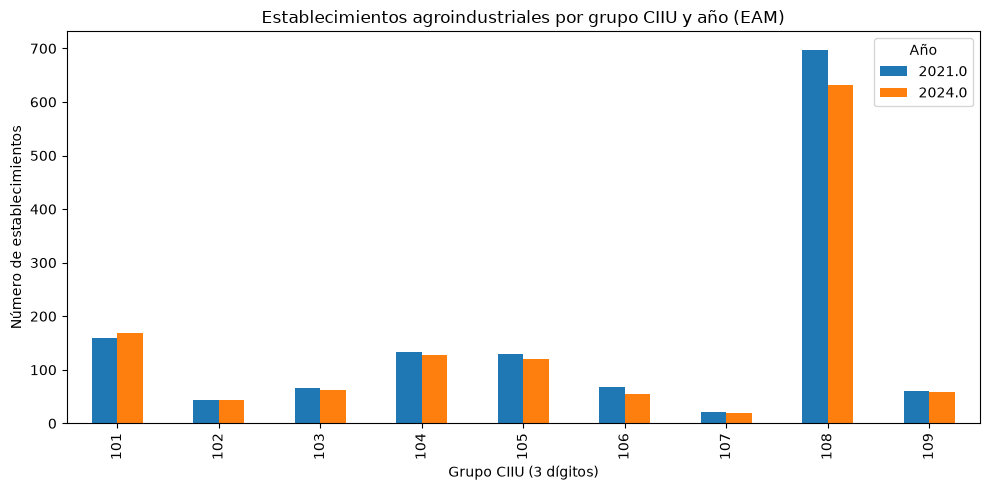

In [6]:
conteo.plot(kind="bar", figsize=(10, 5))
plt.title("Establecimientos agroindustriales por grupo CIIU y año (EAM)")
plt.xlabel("Grupo CIIU (3 dígitos)")
plt.ylabel("Número de establecimientos")
plt.legend(title="Año")
plt.tight_layout()
plt.show()